### Import important libraries

In [35]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the file

In [36]:
df = pd.read_csv('standardscaler_.csv')
df.head()

,Experience_Years,Age,Education_Level,Hours_Per_Week,Salary
0,5.99,34.63,3,41.12,87638.54
1,4.72,39.55,4,46.82,84956.80
2,6.30,23.01,1,40.63,73501.52
3,8.05,32.81,4,37.85,100707.27
4,4.53,26.75,3,40.61,80094.46


### Find the corelation matrix

In [37]:
df.corr(numeric_only=True)

,Experience_Years,Age,Education_Level,Hours_Per_Week,Salary
Experience_Years,1.000000,-0.073255,-0.071472,0.060724,0.514034
Age,-0.073255,1.000000,-0.004516,0.047329,-0.010178
Education_Level,-0.071472,-0.004516,1.000000,0.006592,0.323822
Hours_Per_Week,0.060724,0.047329,0.006592,1.000000,0.083765
Salary,0.514034,-0.010178,0.323822,0.083765,1.000000


### Boxplot to visualize the outliers

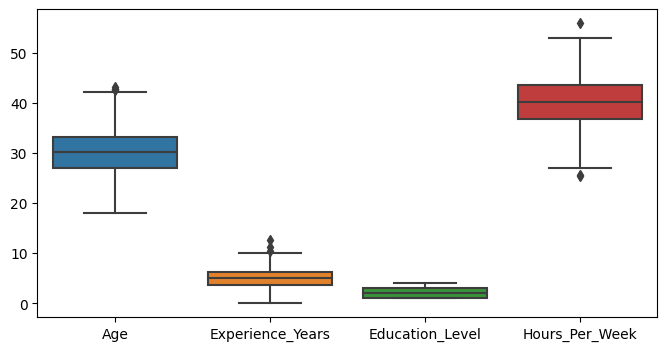

In [38]:
plt.figure(figsize=(8, 4))
sns.boxplot(df[['Age', 'Experience_Years', 'Education_Level', 'Hours_Per_Week']])
plt.show()

### Creating objects for the different Scaling classes

In [39]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
minMax_scaler = MinMaxScaler()

### Seperated feature and target column

In [40]:
x = df.drop(columns='Salary')
y = df['Salary']

### Spliting the data to train-test

In [41]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

### Perform scaling respectively

In [42]:
xtrain[['Age', 'Experience_Years', 'Hours_Per_Week']] = standard_scaler.fit_transform(xtrain[['Age', 'Experience_Years', 'Hours_Per_Week']])
xtest[['Age', 'Experience_Years', 'Hours_Per_Week']] = standard_scaler.transform(xtest[['Age', 'Experience_Years', 'Hours_Per_Week']])

In [43]:
xtrain['Education_Level'] = minMax_scaler.fit_transform(xtrain[['Education_Level']])
xtest['Education_Level'] = minMax_scaler.transform(xtest[['Education_Level']])

In [44]:
xtrain.mean()

Experience_Years    1.365574e-16
Age                -6.572520e-16
Education_Level     4.958333e-01
Hours_Per_Week      2.575717e-16
dtype: float64

In [45]:
xtrain.std()

Experience_Years    1.001252
Age                 1.001252
Education_Level     0.370876
Hours_Per_Week      1.001252
dtype: float64